# Data Centre Hosting Recommendations

This notebook supports the second half of the presentation.

It adds direct evidence from external sources on:

- data-centre electricity demand
- water footprint concerns
- sustainable hosting considerations
- Canada-specific infrastructure context


## Sources to use for recommendations

1. IEA Energy and AI
   - use for direct AI and data-centre electricity demand context

2. EU data-centre reporting / water footprint sources
   - use for direct water footprint framing

3. Canada Energy Regulator / NRCan
   - use for Canada-specific hosting and infrastructure context

4. OWID electricity mix
   - use to support sustainability comparisons across countries


## Recommendation themes

- Prefer locations with stronger low-carbon electricity mixes
- Do not judge sustainability based on electricity quantity alone
- Consider water stress / water withdrawal alongside energy availability
- Use Canada's cleaner electricity regions as a strategic hosting advantage


In [78]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1. Open Data loading
# ==============================
# Main Dataset: Our World in Data (energy)
owid_url = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"

# Ireland: Official CSO data center electricity consumption statistics
ireland_xlsx = "https://www.cso.ie/en/media/csoie/releasespublications/documents/ep/datacentresmeteredelectricityconsumption/2024/P-DCMEC2024TBL1.xlsx"

energy = pd.read_csv(owid_url)

In [79]:
energy.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [80]:
energy.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='str', length=130)

In [81]:
energy.shape

(23232, 130)

In [82]:
energy[energy['year'] == 2024]['country'].unique()

<StringArray>
[                'ASEAN (Ember)',                        'Africa',
                   'Africa (EI)',                'Africa (Ember)',
                       'Algeria',                        'Angola',
                     'Argentina',                       'Armenia',
                          'Asia',                  'Asia (Ember)',
 ...
 'Upper-middle-income countries',                       'Uruguay',
                    'Uzbekistan',                     'Venezuela',
                       'Vietnam',           'Western Africa (EI)',
                         'World',                         'Yemen',
                        'Zambia',                      'Zimbabwe']
Length: 178, dtype: str

## Country analysis


**Questions**

1. Does Canada have an environmental advantage for hosting AI/data centers?
2. Does this growth come with a downside—pressure on the power grid, the network, and electricity availability?


In [83]:
year_count = energy.groupby('year').size().rename('count').reset_index()
year_count_last = year_count[year_count['year'] > 2015]
year_count_last

,year,count
116,2016,308
117,2017,294
118,2018,294
119,2019,294
120,2020,293
121,2021,293
122,2022,293
123,2023,293
124,2024,178
125,2025,37


In [84]:
start_year = 2015
latest_year = energy['year'].max()
peer_countries = ['Canada', 'Ireland', 'France', 'Norway', 'Sweden', 'Mexico', 'South Korea', 'Turkey', 'Chad', 'Chile', 'China', 'Colombia',
                  'Congo', 'Costa Rica', 'Croatia', 'Cuba', 'Curacao', 'Cyprus','Czechia', 'Democratic Republic of Congo', 'Denmark',
                  'Ukraine', 'United Arab Emirates', 'United Kingdom']
print(f'latest year : {latest_year}')

latest year : 2025


In [85]:
cols_to_stay = [
    "country",
    "year",
    "electricity_demand",
    "low_carbon_share_elec",
    "renewables_share_elec",
    "fossil_share_elec",
    "carbon_intensity_elec",
]

1.  1.country = country
2.  year = year
3.  demand = total electricity demand in the country for the year
4.  low_carbon_share_elec — the share of electricity generated from low-carbon sources, as a percentage.
    Low-carbon sources here are primarily renewable energy sources and nuclear energy.
    For example, if a country's low_carbon_share_elec = 80, this means that approximately 80% of its electricity is generated without fossil fuels.
5.  carbon_intensity_elec — the carbon intensity of electricity.
    This shows how much CO₂ is emitted per 1 kWh of electricity, measured in grams of CO₂ per kWh (gCO₂/kWh).
    The lower this number, the cleaner a country's electricity.


In [86]:
df = energy.loc[
    energy["country"].isin(peer_countries) & energy["year"].between(start_year, latest_year),
    cols_to_stay,
].copy()

In [87]:
df.head()

,country,year,electricity_demand,low_carbon_share_elec,renewables_share_elec,fossil_share_elec,carbon_intensity_elec
3903,Canada,2015,601.55,79.134,63.841,20.866,184.37
3904,Canada,2016,603.33,79.662,64.565,20.338,180.88
3905,Canada,2017,607.11,80.849,65.819,19.151,172.06
3906,Canada,2018,613.00,80.675,65.546,19.325,170.86
3907,Canada,2019,608.62,80.708,65.382,19.292,169.99


In [88]:
df.shape

(250, 7)

In [89]:
df.groupby('country').agg({'year' : 'max'})

,year
country,
Canada,2024
Chad,2024
Chile,2024
China,2024
Colombia,2024
Congo,2024
Costa Rica,2024
Croatia,2025
Cuba,2024


In [90]:
## Canada is missing 2025

In [91]:
df = df[df['year'] != 2025]
df.groupby('country').agg({'year' : 'max'})

,year
country,
Canada,2024
Chad,2024
Chile,2024
China,2024
Colombia,2024
Congo,2024
Costa Rica,2024
Croatia,2024
Cuba,2024


In [92]:
df2024 = (
    df.loc[df["year"] == 2024]
    .copy()
    .sort_values("carbon_intensity_elec")
)

df2024 = df2024.dropna(subset = ['electricity_demand', 'low_carbon_share_elec', 'renewables_share_elec', 'fossil_share_elec', 'carbon_intensity_elec'])

df2024.head()

,country,year,electricity_demand,low_carbon_share_elec,renewables_share_elec,fossil_share_elec,carbon_intensity_elec
15066,Norway,2024,137.68,98.392,98.392,1.608,30.75
19890,Sweden,2024,138.55,98.791,69.330,1.209,34.89
7760,France,2024,470.13,94.883,26.959,5.117,40.83
4958,Costa Rica,2024,11.53,94.023,94.023,5.977,63.01
5768,Denmark,2024,38.89,89.227,89.227,10.773,131.33


In [93]:
df2024.shape

(18, 7)

In [94]:
df2024["mtco2_for_extra_1twh"] = df2024["carbon_intensity_elec"] / 1000
df2024

,country,year,electricity_demand,low_carbon_share_elec,renewables_share_elec,fossil_share_elec,carbon_intensity_elec,mtco2_for_extra_1twh
15066,Norway,2024,137.68,98.392,98.392,1.608,30.75,0.03075
19890,Sweden,2024,138.55,98.791,69.330,1.209,34.89,0.03489
7760,France,2024,470.13,94.883,26.959,5.117,40.83,0.04083
4958,Costa Rica,2024,11.53,94.023,94.023,5.977,63.01,0.06301
5768,Denmark,2024,38.89,89.227,89.227,10.773,131.33,0.13133
5117,Croatia,2024,19.48,73.148,73.148,26.852,172.62,0.17262
3912,Canada,2024,624.29,77.694,64.272,22.306,185.35,0.18535
21731,United Kingdom,2024,317.35,64.932,50.648,35.068,216.50,0.21650
4450,Chile,2024,89.26,69.897,69.897,30.103,265.18,0.26518
10133,Ireland,2024,36.02,46.027,46.027,53.973,273.26,0.27326


In [95]:
# ==============================
# 3. Key numerical findings
# ==============================
china = df2024.loc[df2024["country"] == "China"].iloc[0]
canada = df2024.loc[df2024["country"] == "Canada"].iloc[0]
ireland = df2024.loc[df2024["country"] == "Ireland"].iloc[0]
france = df2024.loc[df2024["country"] == "France"].iloc[0]

print("\n=== Key findings ===")
print(
    f"Positive conclusion: In Canada, the carbon intensity of electricity = {canada['carbon_intensity_elec']:.1f} g CO2/kWh, "
    f"in China = {ireland['carbon_intensity_elec']:.1f} g CO2/kWh."
)
print(
    f"If a data center consumes an additional 1 TWh, this would result in approximately {canada['mtco2_for_extra_1twh']:.3f} MtCO2 in Canada "
    f"versus {china['mtco2_for_extra_1twh']:.3f} MtCO2 in China."
)
print(
    f"Negative conclusion: Canada is not the best in terms of electricity cleanliness. "
    f"Its carbon intensity is approximately {canada['carbon_intensity_elec'] / france['carbon_intensity_elec']:.2f} times higher than France's."
)


=== Key findings ===
Positive conclusion: In Canada, the carbon intensity of electricity = 185.3 g CO2/kWh, in China = 273.3 g CO2/kWh.
If a data center consumes an additional 1 TWh, this would result in approximately 0.185 MtCO2 in Canada versus 0.555 MtCO2 in China.
Negative conclusion: Canada is not the best in terms of electricity cleanliness. Its carbon intensity is approximately 4.54 times higher than France's.


In [96]:
# ==============================
# 4. Ireland as a warning case
# ==============================
ireland_dc = pd.read_excel(ireland_xlsx, skiprows=2)
ireland_dc = ireland_dc.iloc[:, :5].copy()
ireland_dc.columns = [
    "year",
    "data_centres_gwh",
    "other_metered_customers_gwh",
    "total_gwh",
    "pct_data_centres",
]

ireland_dc = ireland_dc.dropna(subset=["year"]).copy()
ireland_dc["year"] = pd.to_numeric(ireland_dc["year"], errors="coerce")
ireland_dc = ireland_dc.dropna(subset=["year"]).copy()
ireland_dc["year"] = ireland_dc["year"].astype(int)

for col in ["data_centres_gwh", "other_metered_customers_gwh", "total_gwh", "pct_data_centres"]:
    ireland_dc[col] = pd.to_numeric(ireland_dc[col], errors="coerce")

ireland_dc = ireland_dc.loc[ireland_dc["year"].between(2015, 2024)].copy()

share_2015 = ireland_dc.loc[ireland_dc["year"] == 2015, "pct_data_centres"].iloc[0]
share_2024 = ireland_dc.loc[ireland_dc["year"] == 2024, "pct_data_centres"].iloc[0]

print(
    f"Ireland as a warning case: the share of data centres in metered electricity increased from {share_2015:.0f}% in 2015 to {share_2024:.0f}% in 2024."
)

Ireland as a warning case: the share of data centres in metered electricity increased from 5% in 2015 to 22% in 2024.


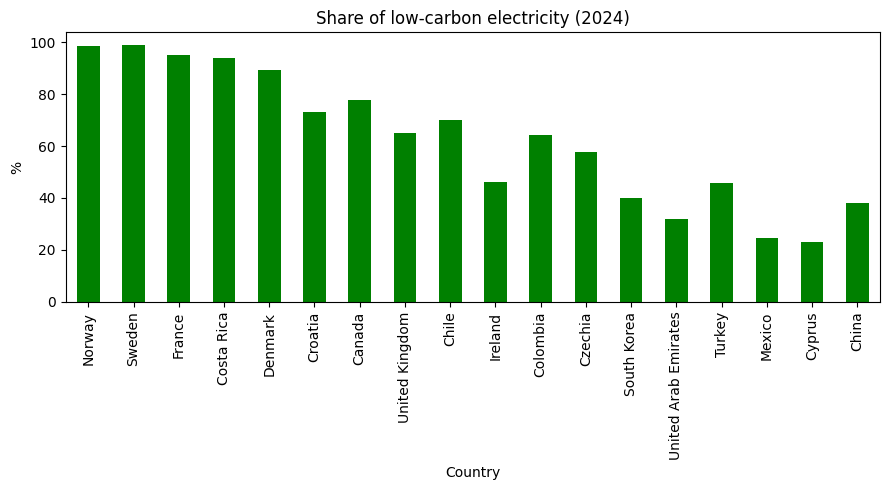

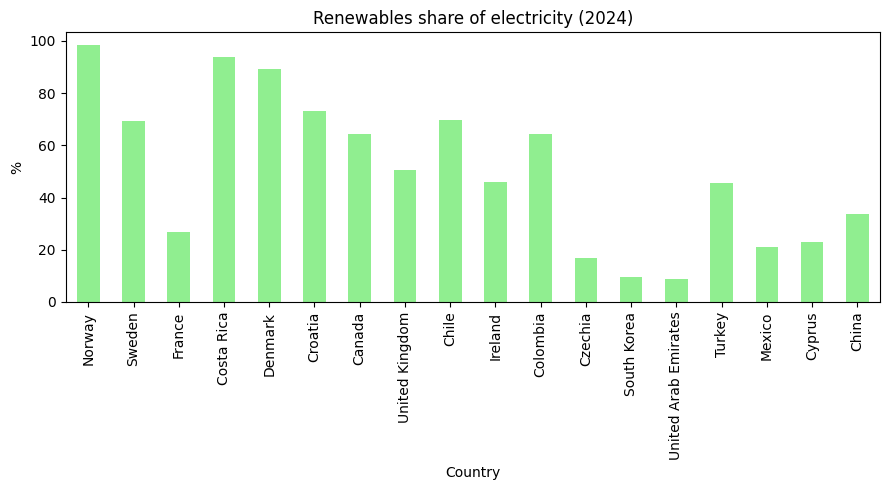

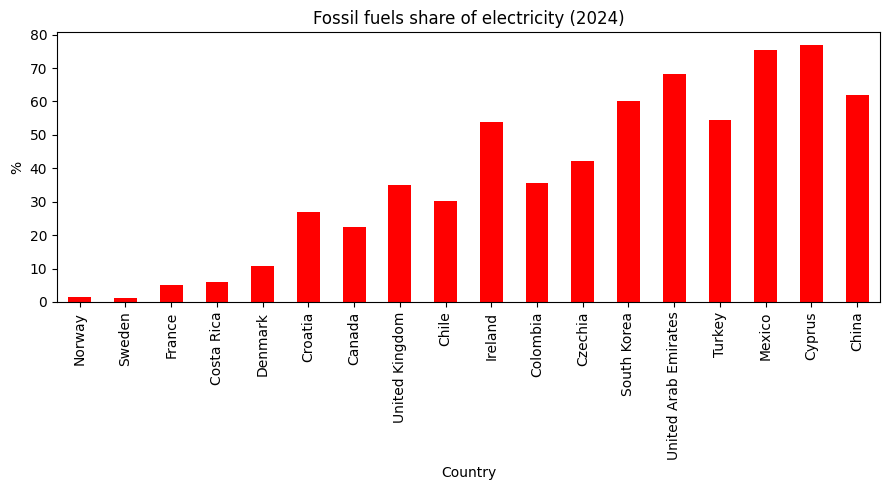

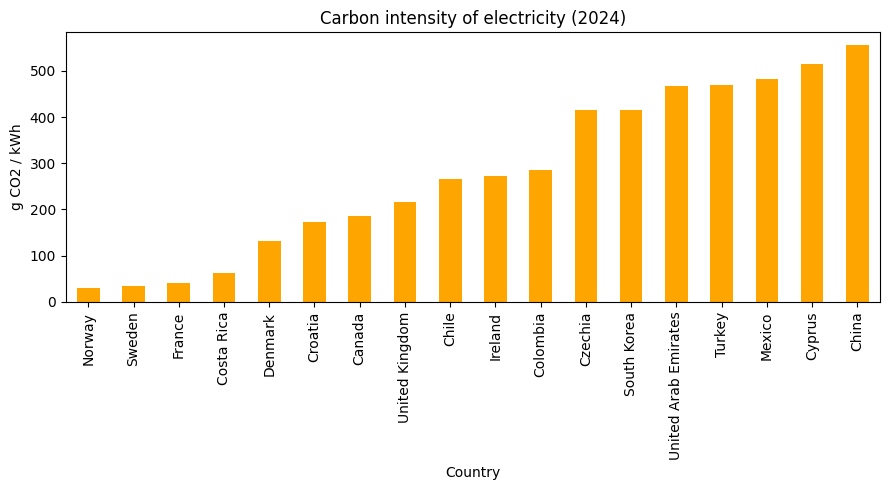

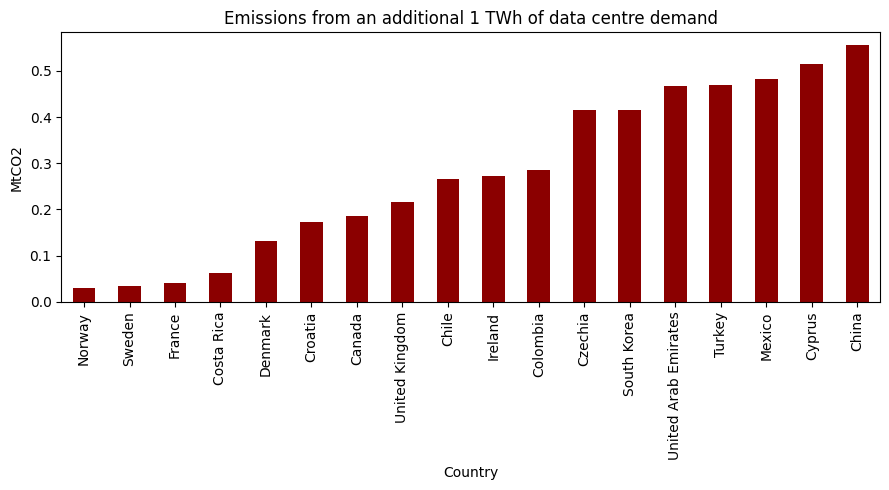

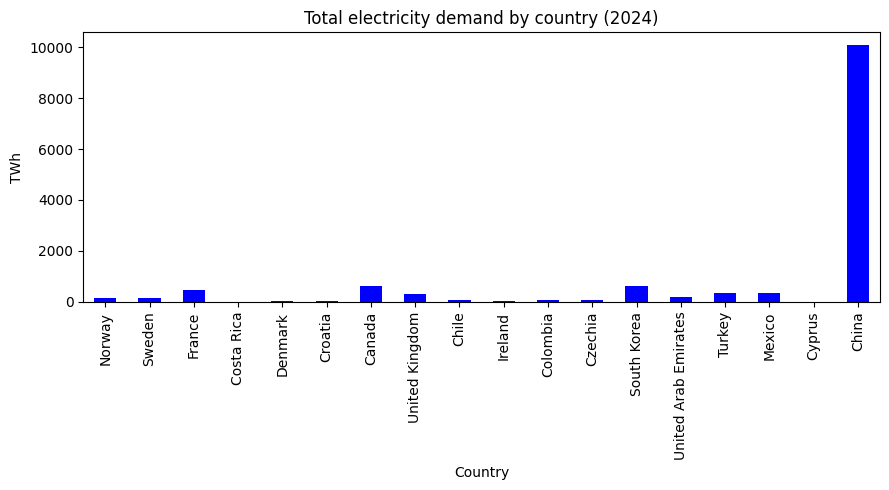

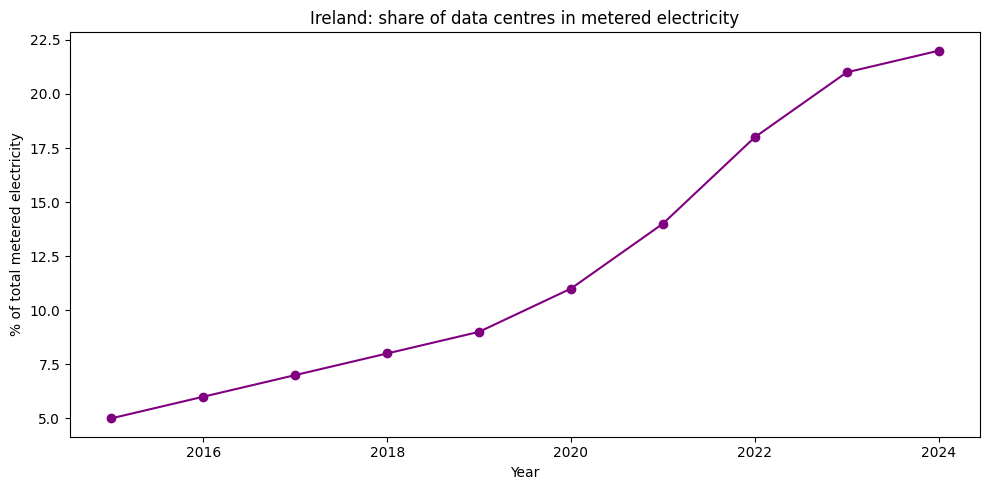

In [97]:
# ==============================
# 5. Visuals
# ==============================
# Chart 1: Share of low-carbon electricity
df2024.set_index("country")["low_carbon_share_elec"].plot(
    kind="bar", figsize=(9, 5), title="Share of low-carbon electricity (2024)", color='green'
)
plt.ylabel("%")
plt.xlabel("Country")
plt.tight_layout()
plt.show()

# Chart 2: Renewables share of electricity
df2024.set_index("country")["renewables_share_elec"].plot(
    kind="bar", figsize=(9, 5), title="Renewables share of electricity (2024)", color='lightgreen'
)
plt.ylabel("%")
plt.xlabel("Country")
plt.tight_layout()
plt.show()

# Chart 3: Fossil fuels share of electricity
df2024.set_index("country")["fossil_share_elec"].plot(
    kind="bar", figsize=(9, 5), title="Fossil fuels share of electricity (2024)", color='red'
)
plt.ylabel("%")
plt.xlabel("Country")
plt.tight_layout()
plt.show()

# Chart 4: Carbon intensity of electricity
df2024.set_index("country")["carbon_intensity_elec"].plot(
    kind="bar", figsize=(9, 5), title="Carbon intensity of electricity (2024)", color='orange'
)
plt.ylabel("g CO2 / kWh")
plt.xlabel("Country")
plt.tight_layout()
plt.show()

# Chart 5: Emissions from an additional 1 TWh of demand
df2024.set_index("country")["mtco2_for_extra_1twh"].plot(
    kind="bar", figsize=(9, 5), title="Emissions from an additional 1 TWh of data centre demand", color='darkred'
)
plt.ylabel("MtCO2")
plt.xlabel("Country")
plt.tight_layout()
plt.show()

# Chart 6: Electricity demand by country
df2024.set_index("country")["electricity_demand"].plot(
    kind="bar", figsize=(9, 5), title="Total electricity demand by country (2024)", color='blue'
)
plt.ylabel("TWh")
plt.xlabel("Country")
plt.tight_layout()
plt.show()

# Chart 7: Ireland as a warning
ireland_dc.set_index("year")["pct_data_centres"].plot(
    kind="line", marker="o", figsize=(10, 5),
    title="Ireland: share of data centres in metered electricity", color='purple'
)
plt.ylabel("% of total metered electricity")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

**Questions**

1. Does Canada have an environmental advantage for hosting AI/data centers?
2. Does this growth come with a downside—pressure on the power grid, the network, and electricity availability?


**Answers**

1. Yes — Canada does have an environmental advantage, because its electricity system is relatively low-carbon, so the same AI/data-centre load can lead to lower emissions than in more fossil-dependent countries. However, this advantage is relative, not absolute: Canada is cleaner than some peers, but not cleaner than the very best low-carbon grids such as Norway, Sweden, or France.

2. Yes — this growth clearly comes with a downside. Even if Canada is environmentally attractive, rapid data-centre expansion can put pressure on grid capacity, connection availability, and electricity affordability.
